Detected P-wave time: 14.98
Detected S-wave time: 23.39
Estimated distance to earthquake: 70.58 km
Estimated Richter Magnitude: 2.34


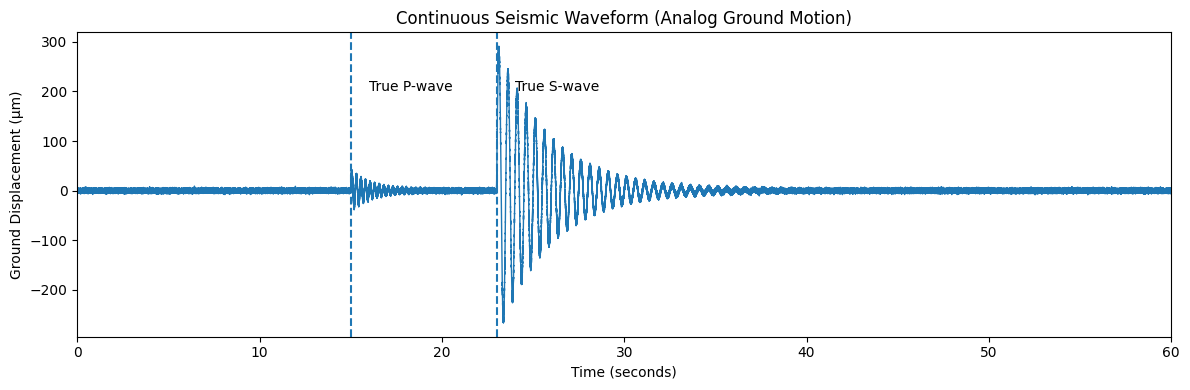

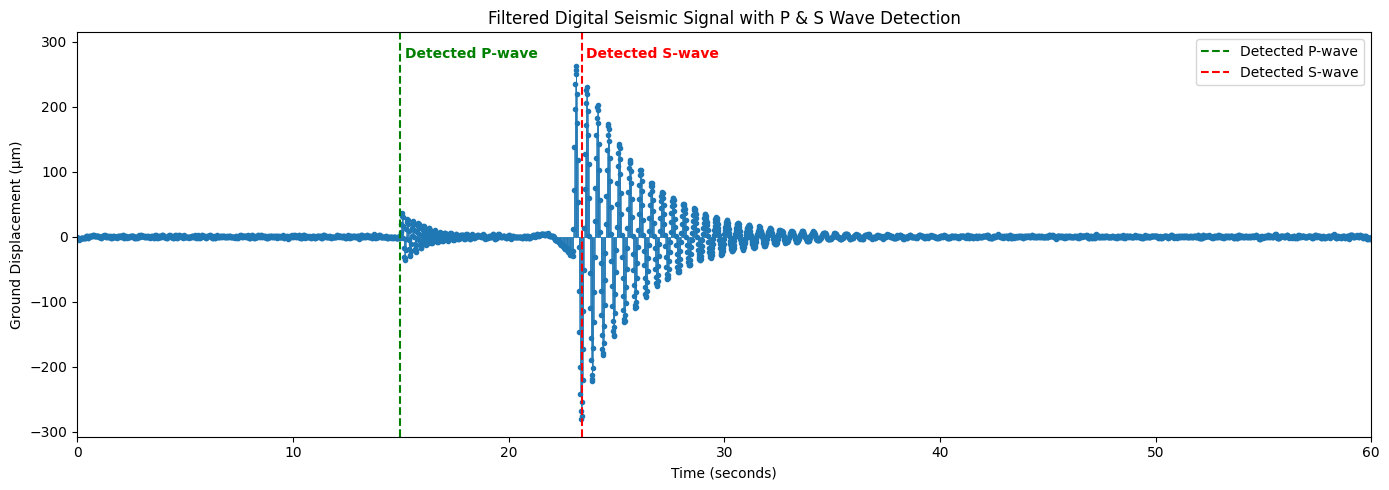

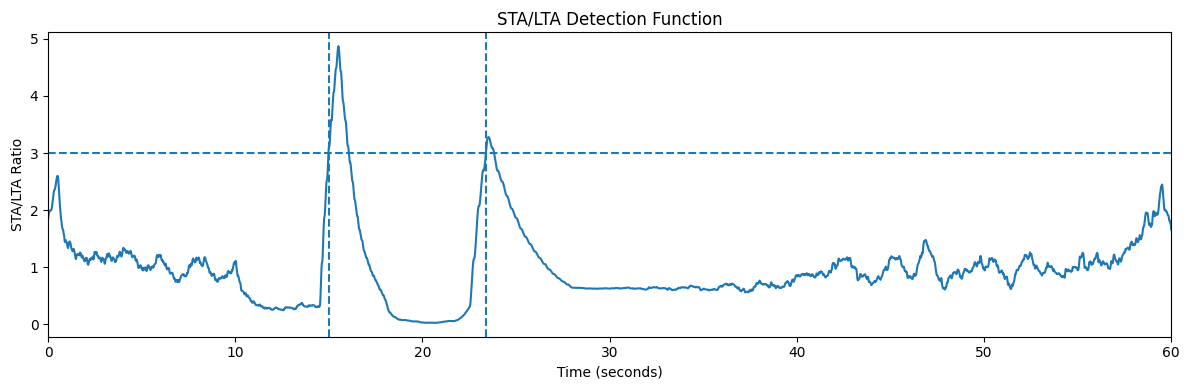

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

duration = 60
fs_cont = 5000
fs_sample = 50

t_cont = np.linspace(0, duration, duration * fs_cont)
t_sample = np.linspace(0, duration, duration * fs_sample)

p_time = 15
s_time = 23

#synthetic seismic signal generation
def generate_seismic(t):

    noise = 2 * np.random.randn(len(t))   # slightly higher noise

    # New earthquake parameters
    p_time = 15
    s_time = 23

    # P-wave
    p_wave = 40*np.sin(2*np.pi*4*(t-p_time)) * np.exp(-0.9*(t-p_time))
    p_wave[t < p_time] = 0

    # S-wave (stronger)
    s_wave = 300*np.sin(2*np.pi*2*(t-s_time)) * np.exp(-0.35*(t-s_time))
    s_wave[t < s_time] = 0

    return noise + p_wave + s_wave

continuous_wave = generate_seismic(t_cont)
sampled_wave = generate_seismic(t_sample)

# Bandpass filter to remove out any noise
lowcut = 0.5
highcut = 10

nyquist = fs_sample / 2
low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(4, [low, high], btype='band')
filtered_wave = filtfilt(b, a, sampled_wave)

#STA/LTA detection
sta_window = int(1 * fs_sample)
lta_window = int(10 * fs_sample)

sta = np.convolve(np.abs(filtered_wave),
                  np.ones(sta_window)/sta_window,
                  mode='same')

lta = np.convolve(np.abs(filtered_wave),
                  np.ones(lta_window)/lta_window,
                  mode='same')

ratio = sta / (lta + 1e-6)
threshold = 3

#P wave detection
p_detect_index = np.argmax(ratio > threshold)
p_detect_time = t_sample[p_detect_index]

#S wave detection
skip_time = 3
skip_samples = int(skip_time * fs_sample)

search_start = p_detect_index + skip_samples

s_detect_index_rel = np.argmax(ratio[search_start:] > threshold)
s_detect_index = search_start + s_detect_index_rel
s_detect_time = t_sample[s_detect_index]

print("Detected P-wave time:", round(p_detect_time,2))
print("Detected S-wave time:", round(s_detect_time,2))

#distance of the epicenter from the station - gives the radius of a circle along which the epicentre may lie
Vp = 6
Vs = 3.5

delta_t = s_detect_time - p_detect_time
distance = (Vp * Vs / (Vp - Vs)) * delta_t
print("Estimated distance to earthquake:", round(distance,2), "km")

#richter scale magnitude approximation
window_samples = int(5 * fs_sample)
start = s_detect_index
end = s_detect_index + window_samples

A = np.max(np.abs(filtered_wave[start:end]))   # micrometers

ML = np.log10(A) - (1.11*np.log10(distance) + 0.00189*distance - 2.09)
print("Estimated Richter Magnitude:", round(ML,2))

#plotting of the continous seismic signal
plt.figure(figsize=(12,4))
plt.plot(t_cont, continuous_wave, linewidth=1)

plt.axvline(p_time, linestyle="--")
plt.axvline(s_time, linestyle="--")

plt.text(p_time+1, 200, "True P-wave")
plt.text(s_time+1, 200, "True S-wave")

plt.title("Continuous Seismic Waveform (Analog Ground Motion)")
plt.xlabel("Time (seconds)")
plt.ylabel("Ground Displacement (µm)")

plt.xlim(0,60)
plt.tight_layout()
plt.show()

#plotting of the filtered digital signal
plt.figure(figsize=(14,5))

markerline, stemlines, baseline = plt.stem(t_sample, filtered_wave, linefmt='C0-', markerfmt='C0o', basefmt='C0-')
plt.setp(stemlines, linewidth=0.5)
plt.setp(markerline, markersize=3)
plt.setp(baseline, linewidth=0.5)


plt.axvline(p_detect_time, color='green', linestyle='--', linewidth=1.5, label='Detected P-wave')
plt.axvline(s_detect_time, color='red', linestyle='--', linewidth=1.5, label='Detected S-wave')


plt.text(p_detect_time + 0.2, np.max(filtered_wave)*1.05, "Detected P-wave", color='green', fontweight='bold')
plt.text(s_detect_time + 0.2, np.max(filtered_wave)*1.05, "Detected S-wave", color='red', fontweight='bold')

plt.title("Filtered Digital Seismic Signal with P & S Wave Detection")
plt.xlabel("Time (seconds)")
plt.ylabel("Ground Displacement (µm)")

plt.xlim(0, duration)
plt.ylim(np.min(filtered_wave)*1.1, np.max(filtered_wave)*1.2)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#sta/lta ratio plotting
plt.figure(figsize=(12,4))
plt.plot(t_sample, ratio)

plt.axhline(threshold, linestyle="--")
plt.axvline(p_detect_time, linestyle="--")
plt.axvline(s_detect_time, linestyle="--")

plt.title("STA/LTA Detection Function")
plt.xlabel("Time (seconds)")
plt.ylabel("STA/LTA Ratio")

plt.xlim(0,60)
plt.tight_layout()
plt.show()